# Financial Trading with Python, 2nd Edition

Cordell L. Tanny, CFA, FRM, FDP

**Chapter 13: Algorithmic Trading Strategies**

Notebook 13.6: US ETF Momentum (Classic 12-0)

Version: 1.0

Last revised: 2026-05-31

**A 12-month lookback, top-five rotation that hunts for winners across stocks, bonds, and commodities.**

> Save a copy to your own Drive before running: File > Save a copy in Drive. Edits to the shared notebook are not preserved.

> Before running, drag `functions.py` and `vectorbt_harness.py` into the Colab session file panel. These files reset whenever the runtime disconnects, so you will need to re-add them after any disconnect.

## 1.0 Introduction

The classic momentum strategy rests on one of the most durable findings in quantitative finance: assets that have gone up over the past several months tend to keep going up over the next month. Jegadeesh and Titman documented this in 1993 for individual US stocks, and the pattern has since held up across decades, markets, and asset classes.

In this notebook we build the textbook version of that strategy, the 12-0 momentum rule. We rank every fund in our universe by its trailing 12-month return, buy the top five in equal weight, hold for one month, and repeat. There is no forecast, no filter, and no defensive switch. The strategy simply owns whatever has been winning.

The universe deliberately spans three asset classes: 40 equity ETFs, 9 fixed income ETFs, and 9 commodity and alternative ETFs. That breadth is the point. When stocks lead, the strategy holds stocks. When stocks break down and gold or bonds take over, the ranking rotates the portfolio into them without us telling it to. This is how a single momentum rule becomes a dynamic asset allocation engine.

In this notebook we will:

- Define a 58-ticker universe spanning equities, fixed income, and commodities
- Download daily adjusted prices with yfinance and resample to monthly
- Calculate 12-month momentum scores and rank the universe each month
- Select the top five funds in equal weight and build a sparse weights file
- Run the strategy through the vectorbt harness with and without trading costs
- Compare the result against a buy-and-hold position in SPY

## 2.0 Setup: Imports and Configuration

Before anything else, the notebook prepares its own environment. It pulls the two helper modules and the package list from the book's repository, so nothing has to be uploaded into the session by hand.

Package versions live in one file in the repository rather than being written into each notebook. When a pinned version stops resolving, and eventually it will, the fix is a single commit instead of an edit to every notebook in the chapter.

This cell also sets where price data comes from. The `USE_SAVED_PRICES` flag controls it:

- `True`, the default, reads prices from files stored in the repository. Every figure printed in this chapter came from those exact files, so your results will match the book.
- `False` downloads fresh data from Yahoo Finance. The notebook still runs end to end, but your numbers will differ from the printed ones.

The reason for the saved files is worth stating. Yahoo recomputes its entire adjusted price history whenever a new dividend or split is recorded, so a series downloaded today is not the series downloaded last month, and across a twenty-year window those revisions compound. Without fixed data, a reader whose numbers differ has no way to tell whether the cause is data drift at the source or a mistake in their own setup.

In [1]:
# --- Environment and data source -------------------------------------------
# Fetches the helper modules and the package list from the book repository,
# installs, and reports what actually landed. Nothing needs uploading by hand.

import os, sys, subprocess, importlib

# True  : read prices from the saved files, results match the book
# False : download fresh from Yahoo, results will differ
USE_SAVED_PRICES = True

REPO_RAW = ('https://raw.githubusercontent.com/PacktPublishing/'
            'Hands-on-Financial-Trading-with-Python-Second-Edition/main')
SCRIPTS_URL = f'{REPO_RAW}/FINAL/python_scripts'
DATA_URL    = f'{REPO_RAW}/FINAL/chapter13/data_files'
REQS_URL    = f'{REPO_RAW}/FINAL'

# Versions this chapter was written against. Used only for the report below.
TESTED = {'python': '3.13', 'numpy': '2.1.3', 'pandas': '2.2.3',
          'vectorbt': '0.28.5', 'pyarrow': '18.1.0', 'yfinance': '0.2.66'}


def fetch(fname, url_base):
    """Download a file into the session if it is not already there."""
    if os.path.exists(fname):
        print(f'  using local {fname}')
        return fname
    subprocess.run(['wget', '-q', f'{url_base}/{fname}'])
    if not os.path.exists(fname):
        raise FileNotFoundError(f'Could not fetch {fname} from {url_base}')
    print(f'  fetched {fname}')
    return fname


def fetch_data_file(fname):
    """Return a local path to a saved data file, downloading it once if needed."""
    return fetch(fname, DATA_URL)


# A pinned package with no wheel for your Python does not fail cleanly: pip
# tries to build from source and the runtime usually dies first. Checking here
# turns that into a readable message.
PY = f'{sys.version_info.major}.{sys.version_info.minor}'
if PY != TESTED['python']:
    print(f'NOTE: this chapter was tested on Python {TESTED["python"]}; you are on {PY}.')
    print('      If the install below hangs, a pinned package has no wheel for '
          'your Python.\n')

fetch('requirements-ch13.txt', REQS_URL)
fetch('functions.py', SCRIPTS_URL)
fetch('vectorbt_harness.py', SCRIPTS_URL)

# No -q here. A silent install that fails leaves you debugging an ImportError
# several cells later instead of reading the actual error now.
print('\nInstalling...')
!pip install -r requirements-ch13.txt 2>&1 | tail -6

print(f'\n{"package":<12}{"installed":<14}{"tested":<12}')
print('-' * 38)
print(f'{"python":<12}{PY + "." + str(sys.version_info.micro):<14}{TESTED["python"]:<12}')
for pkg in ['numpy', 'pandas', 'pyarrow', 'vectorbt', 'numba', 'yfinance']:
    try:
        v = importlib.import_module(pkg).__version__
    except Exception:
        v = 'not installed'
    flag = '' if TESTED.get(pkg) in (None, v) else '  <- differs'
    print(f'{pkg:<12}{v:<14}{TESTED.get(pkg, "-"):<12}{flag}')

print(f'\nUSE_SAVED_PRICES = {USE_SAVED_PRICES}'
      f'  ({"saved files, results match the book" if USE_SAVED_PRICES else "live download, results will differ"})')

  fetched requirements-ch13.txt
  fetched functions.py
  fetched vectorbt_harness.py

Installing...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.9/4.9 MB 32.9 MB/s eta 0:00:00

package     installed     tested      
--------------------------------------
python      3.13.15       3.13        
numpy       2.1.3         2.1.3       
pandas      2.2.3         2.2.3       
pyarrow     18.1.0        18.1.0      
vectorbt    0.28.5        0.28.5      
numba       0.61.2        -           
yfinance    0.2.66        0.2.66      

USE_SAVED_PRICES = True  (saved files, results match the book)


Before any analysis, we import our libraries and gather every user-defined choice into one configuration block. The packages and the two helper files were already fetched and installed by the setup cell above. The question this section answers: what are the moving parts of the strategy, and where do we change them?

Centralizing the parameters means you can re-run the entire strategy with a different lookback, a different number of holdings, or a different cost assumption by editing one place, without hunting through the notebook. The config block below is the only cell you should need to touch to experiment.

The two helper files come from the book repository: functions.py holds the performance metrics we score with, and vectorbt_harness.py runs the backtest from a weights file. If you have your own copies in the session, those are used instead.

In [2]:
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns

sns.set_theme()

# The harness and metrics toolkit were fetched into the session by the setup
# cell above, so nothing needs dragging in by hand.
from vectorbt_harness import run_backtest
import functions as fn

# ============================================================
# CONFIGURATION  (edit here to experiment)
# ============================================================

# --- Strategy rules ---
LOOKBACK_MONTHS = 12      # trailing window for the momentum score (the "12" in 12-0)
TOP_N           = 5       # number of funds held each month, equal weighted
HOLD_MONTHS     = 1       # rebalance frequency in months

# --- Data window ---
START_DATE = "2003-01-01"  # pulled early so young ETFs enter the rank as they list
END_DATE   = "2026-05-31"  # fixed end date shared across all Chapter 13 notebooks

# --- Benchmark ---
BENCHMARK = "SPY"          # buy-and-hold comparison

# --- Backtest costs (chapter standard) ---
FEES_BPS     = 10          # commission, in basis points per trade
SLIPPAGE_BPS = 5           # slippage, in basis points per trade

# --- Output file ---
WEIGHTS_CSV = "momentum_12_0_weights.csv"

# ============================================================
# ASSET UNIVERSE
# ============================================================

equity_etfs = {
    "QQQ": "Invesco QQQ Trust",
    "VTI": "Vanguard Total Stock Market ETF",
    "VYM": "Vanguard High Dividend Yield ETF",
    "IWM": "iShares Russell 2000 ETF",
    "SMDV": "ProShares Russell 2000 Dividend Growers",
    "SPYG": "SPDR Portfolio S&P 500 Growth ETF",
    "IWF": "iShares Russell 1000 Growth ETF",
    "VO": "Vanguard Mid-Cap ETF",
    "VBR": "Vanguard Small-Cap Value ETF",
    "VOE": "Vanguard Mid-Cap Value ETF",
    "SPGP": "Invesco S&P 500 GARP ETF",
    "REGL": "S&P MidCap 400 Dividend Aristocrats ETF",
    "IWV": "iShares Russell 3000 ETF",
    "XLF": "Financial Select Sector SPDR Fund",
    "XLE": "Energy Select Sector SPDR Fund",
    "XLK": "Technology Select Sector SPDR Fund",
    "XLV": "Health Care Select Sector SPDR Fund",
    "XLY": "Consumer Discretionary Select Sector SPDR Fund",
    "XLI": "Industrial Select Sector SPDR Fund",
    "XLP": "Consumer Staples Select Sector SPDR Fund",
    "XLU": "Utilities Select Sector SPDR Fund",
    "XLC": "Communication Services Select Sector SPDR Fund",
    "SOXX": "iShares Semiconductor ETF",
    "MOAT": "VanEck Morningstar Wide Moat ETF",
    "ARKK": "ARK Innovation ETF",
    "ARKG": "ARK Genomic Revolution ETF",
    "ARKW": "ARK Next Generation Internet ETF",
    "SDY": "SPDR S&P Dividend ETF",
    "USMV": "iShares Edge MSCI Min Vol USA ETF",
    "HDV": "iShares Core High Dividend ETF",
    "DIA": "SPDR Dow Jones Industrial Average ETF Trust",
    "FDN": "First Trust Dow Jones Internet Index Fund",
    "VIG": "Vanguard Dividend Appreciation ETF",
    "FPX": "First Trust US Equity Opportunities ETF",
    "ITB": "iShares U.S. Home Construction ETF",
    "ITA": "iShares U.S. Aerospace & Defense ETF",
    "DES": "WisdomTree U.S. SmallCap Dividend Fund",
    "XMLV": "Invesco S&P MidCap Low Volatility ETF",
    "SPY": "SPDR S&P 500 ETF Trust",
    "QTUM": "Defiance Quantum ETF",
}

fixed_income_etfs = {
    "TLT": "iShares 20+ Year Treasury Bond ETF",
    "IEF": "iShares 7-10 Year Treasury Bond ETF",
    "SHY": "iShares 1-3 Year Treasury Bond ETF",
    "BIL": "SPDR Bloomberg 1-3 Month T-Bill ETF",
    "AGG": "iShares Core U.S. Aggregate Bond ETF",
    "LQD": "iShares iBoxx $ Investment Grade Corporate Bond ETF",
    "HYG": "iShares iBoxx $ High Yield Corporate Bond ETF",
    "MBB": "iShares MBS ETF",
    "PFF": "iShares Preferred and Income Securities ETF",
}

other_etfs = {
    "GLD": "SPDR Gold Shares",
    "SLV": "iShares Silver Trust",
    "DBC": "Invesco DB Commodity Index Tracking Fund",
    "USO": "United States Oil Fund",
    "PICK": "iShares MSCI Global Metals & Mining Producers ETF",
    "UUP": "Invesco DB US Dollar Index Bullish Fund",
    "GDX": "VanEck Vectors Gold Miners ETF",
    "GDXJ": "VanEck Vectors Junior Gold Miners ETF",
    "DBA": "Invesco DB Agriculture Fund",
}

# Combine all tickers for data loading
tickers = list(equity_etfs.keys()) + list(fixed_income_etfs.keys()) + list(other_etfs.keys())

print(f"Universe size: {len(tickers)} tickers")
print(f"  Equity:       {len(equity_etfs)}")
print(f"  Fixed income: {len(fixed_income_etfs)}")
print(f"  Alternative:  {len(other_etfs)}")
print(f"\nLookback: {LOOKBACK_MONTHS} months | Hold: top {TOP_N} | Rebalance: every {HOLD_MONTHS} month(s)")
print(f"Window: {START_DATE} to {END_DATE}")

Universe size: 58 tickers
  Equity:       40
  Fixed income: 9
  Alternative:  9

Lookback: 12 months | Hold: top 5 | Rebalance: every 1 month(s)
Window: 2003-01-01 to 2026-05-31


The universe is confirmed at 58 funds: 40 equity, 9 fixed income, 9 alternative.

Two design points worth stating before we go further:

- **The funds were chosen without looking at their returns.** The list spans broad indexes, sectors, factor tilts, treasuries, credit, and commodities, picked for asset-class coverage, not past performance. If we had screened for winners first, the backtest would inherit a built-in edge that does not exist out of sample. That is data snooping bias, and selecting on coverage rather than results is how we avoid it.

- **The funds do not share an inception date.** The oldest names (the SPDR sectors, VTI, GLD, the treasury ETFs) trade from 2005 or earlier, while others list much later: SMDV and REGL around 2015, QTUM in 2018, SPGP in 2019. This is fine for a momentum strategy. Each month, a fund needs 12 months of price history to earn a momentum score, and any fund without it returns a blank score and simply cannot rank. Young funds therefore enter the selection pool the month they qualify, with no special handling and no lookahead. The universe grows over time on its own.

We pulled the window from 2003 so the early funds have their full history available, while the strategy itself will not produce a first signal until enough funds clear the 12-month bar.

*Note: There will clearly be some extreme sector concentration given the overlap of many of these ETFs.*

## 3.0 Downloading and Resampling Price Data

The question this section answers: where does our price data come from, and at what frequency does the strategy make decisions?

We load daily adjusted prices for all 58 funds, from the saved file or from a live yfinance download depending on the flag set earlier, using auto_adjust=True so that splits and dividends are already baked into the close. A momentum strategy that ignored dividends would understate the return of high-yield holdings like the bond and dividend ETFs, so adjusted prices matter here.

The strategy decides monthly, so we resample the daily closes down to one price per month, the last close of each month. Every momentum score, rank, and weight from here on works off this monthly series.

In [3]:
# Download daily prices for the full universe in one call.
# auto_adjust=True returns split- and dividend-adjusted closes, so total
# return is captured. This matters for the bond and dividend ETFs, whose
# payouts are a large share of their return.
if USE_SAVED_PRICES:
    df_raw = pd.read_parquet(fetch_data_file('ch13_nb06_signal_prices.parquet'))
else:
    df_raw = yf.download(
        tickers,
        start=START_DATE,
        end=END_DATE,
        auto_adjust=True,
        progress=False,
    )

# Keep the adjusted close panel only: columns = tickers, rows = trading days.
df_prices_daily = df_raw["Close"].copy()

# Resample to monthly: take the last available close in each calendar month.
# 'ME' is the month-end frequency. The strategy rebalances on these dates.
df_prices_monthly = df_prices_daily.resample("ME").last()

# Report coverage so we can see when each part of the universe comes online.
print(f"Daily price panel:   {df_prices_daily.shape[0]} rows x {df_prices_daily.shape[1]} tickers")
print(f"Monthly price panel: {df_prices_monthly.shape[0]} rows x {df_prices_monthly.shape[1]} tickers")
print(f"Date range: {df_prices_monthly.index.min().date()} to {df_prices_monthly.index.max().date()}")

# Count how many funds have a valid price in the first vs last month,
# to confirm the universe genuinely grows over time.
first_month_live = df_prices_monthly.iloc[0].notna().sum()
last_month_live  = df_prices_monthly.iloc[-1].notna().sum()
print(f"\nFunds with data in first month ({df_prices_monthly.index.min().date()}): {first_month_live}")
print(f"Funds with data in last month  ({df_prices_monthly.index.max().date()}): {last_month_live}")

  fetched ch13_nb06_signal_prices.parquet
Daily price panel:   5889 rows x 58 tickers
Monthly price panel: 281 rows x 58 tickers
Date range: 2003-01-31 to 2026-05-31

Funds with data in first month (2003-01-31): 21
Funds with data in last month  (2026-05-31): 58


The download gives us a clean monthly panel to work from:

- **Daily panel:** 5,889 trading days across 58 funds
- **Monthly panel:** 281 month-end rows, January 2003 to May 2026
- **Funds live in first month (2003-01-31):** 21
- **Funds live in last month (2026-05-31):** 58

The jump from 21 to 58 confirms the universe grows as expected. Only 21 funds were trading at the start, and the rest enter as they list. None of this requires special handling: a fund with no price simply has no momentum score and cannot be selected, so the strategy widens its choices on its own over time.

With the monthly price series in place, we can calculate momentum.

## 4.0 Calculating Momentum and Ranking the Universe

The question this section answers: how do we measure momentum, and how do we turn it into a monthly buy list?

Momentum here is simply the trailing 12-month total return of each fund, measured at every month-end. This is the 12 in 12-0: a 12-month lookback with no gap before forming the portfolio. A fund that returned 30 percent over the past year scores higher than one that returned 5 percent, and the highest scorers are the winners we want to own.

Once every fund has a score for a given month, we rank them against each other, best to worst. The top five become that month's portfolio. Two practical points the code handles:

- A fund needs a price 12 months ago and a price today to produce a score. Funds missing either get a blank score and drop out of the ranking that month, which is exactly how young funds stay out until they qualify.
- We rank across funds within each month, not through time. This is cross-sectional momentum: who is winning right now relative to peers, not whether a fund beat its own past.

In [4]:
# --- Momentum score: trailing 12-month total return ---
# pct_change over LOOKBACK_MONTHS periods on the monthly series gives the
# return from 12 months ago to today, for every fund on every month-end.
# A fund without a price 12 months back produces NaN and will not rank.
momentum_scores = df_prices_monthly.pct_change(periods=LOOKBACK_MONTHS)

# Drop the warmup rows where no fund has a full 12-month history yet.
momentum_scores = momentum_scores.dropna(how="all")

# --- Cross-sectional rank, best to worst ---
# axis=1 ranks across funds within each month. ascending=False puts the
# highest return at rank 1. NaN scores stay NaN and are never ranked.
df_ranks = momentum_scores.rank(axis=1, ascending=False)

# --- Build the monthly buy list: the TOP_N lowest ranks (1..TOP_N) ---
# For each month, find the funds whose rank is among the smallest TOP_N.
top_etfs = df_ranks.apply(
    lambda row: row.nsmallest(TOP_N).index.tolist(),
    axis=1,
)

# Report when the strategy can first act and how many names it ranks early vs late.
first_signal_date = momentum_scores.dropna(how="all").index[0]
print(f"First month with a momentum score: {first_signal_date.date()}")
print(f"Months of signal available: {len(top_etfs)}")

print(f"\nRankable funds in first signal month: {df_ranks.iloc[0].notna().sum()}")
print(f"Rankable funds in last signal month:  {df_ranks.iloc[-1].notna().sum()}")

print("\nFirst 3 monthly buy lists:")
for date in top_etfs.index[:3]:
    print(f"  {date.date()}: {top_etfs.loc[date]}")

print("\nLast 3 monthly buy lists:")
for date in top_etfs.index[-3:]:
    print(f"  {date.date()}: {top_etfs.loc[date]}")

First month with a momentum score: 2004-01-31
Months of signal available: 269

Rankable funds in first signal month: 21
Rankable funds in last signal month:  58

First 3 monthly buy lists:
  2004-01-31: ['SOXX', 'IWM', 'QQQ', 'XLK', 'XLY']
  2004-02-29: ['SOXX', 'IWM', 'QQQ', 'XLF', 'XLY']
  2004-03-31: ['SOXX', 'IWM', 'XLF', 'QQQ', 'XLK']

Last 3 monthly buy lists:
  2026-03-31: ['SLV', 'GDXJ', 'GDX', 'SOXX', 'USO']
  2026-04-30: ['SOXX', 'USO', 'SLV', 'GDXJ', 'GDX']
  2026-05-31: ['SOXX', 'SLV', 'USO', 'QTUM', 'GDXJ']


The ranking produced a usable signal:

- **First signal month:** 2004-01-31, one year after the data starts, once the earliest funds clear the 12-month lookback
- **Signal months available:** 269
- **Rankable funds:** 21 in the first month, 58 in the last

The buy lists confirm the strategy rotates across asset classes:

- **2004:** entirely equity, led by SOXX, QQQ, IWM, and cyclical sectors
- **2026:** silver (SLV), gold miners (GDX, GDXJ), and oil (USO) alongside semiconductors (SOXX), a commodity and precious-metals tilt

The same 12-month rule selected technology in 2004 and metals in 2026, with no input from us in either case. A stock-only universe could not have produced the 2026 allocation.

Next we convert these buy lists into the sparse weights file the backtest harness expects.

## 5.0 Building the Sparse Weights File

The question this section answers: how do we hand the monthly buy lists to the backtest harness?

The harness reads a sparse weights file. Each row is a rebalance date, each column is a ticker, and each value is a target weight as a decimal. A row appears only when the portfolio changes, and the position is held until the next dated row. The weights are dated to the signal day, the month-end, and fed unshifted. The harness executes at that day's close, so we do not shift the signal ourselves.

Our strategy holds five funds in equal weight, so each selected fund gets 0.20 and everything else is left blank for that row. We write a row whenever the set of five holdings differs from the prior month. Before saving, we check that no row contains a NaN among its held names, that every row sums to 1.0, and that no weight falls outside the expected range.

In [5]:
# --- Convert each monthly buy list into an equal-weight row ---
# Each of the TOP_N selected funds gets an equal share of capital.
equal_weight = 1.0 / TOP_N

# Build a dense weights frame first: rows = signal months, columns = all
# tickers, value = equal_weight where held, NaN where not held. NaN (not 0)
# is the chapter's "not held" marker in a sparse file.
weights_dense = pd.DataFrame(index=top_etfs.index, columns=tickers, dtype=float)

for date, holdings in top_etfs.items():
    weights_dense.loc[date, holdings] = equal_weight

# --- Keep only rows where the held set changes ---
# A row is needed when this month's set of held tickers differs from last
# month's. Comparing the non-null column sets month to month tells us that.
held_sets = weights_dense.apply(lambda row: frozenset(row.dropna().index), axis=1)
changed = held_sets != held_sets.shift(1)
weights_sparse = weights_dense[changed].copy()

# --- Sanity checks before writing ---
# 1. Every held weight present (no NaN among the funds that should be held).
held_counts = weights_sparse.notna().sum(axis=1)
assert (held_counts == TOP_N).all(), "A row does not hold exactly TOP_N funds."

# 2. Each row sums to 1.0 across its held names.
row_sums = weights_sparse.sum(axis=1)
assert np.allclose(row_sums, 1.0), "A row does not sum to 1.0."

# 3. Every weight is within the expected bound.
held_values = weights_sparse.values[~np.isnan(weights_sparse.values)]
assert (held_values > 0).all() and (held_values <= 1.0).all(), "Weight out of bounds."

# --- Write the sparse file ---
weights_sparse.to_csv(WEIGHTS_CSV, float_format="%.6f")

print(f"Sparse weights written to: {WEIGHTS_CSV}")
print(f"Total signal months: {len(weights_dense)}")
print(f"Rows written (held set changed): {len(weights_sparse)}")
print(f"First rebalance: {weights_sparse.index.min().date()}")
print(f"Last rebalance:  {weights_sparse.index.max().date()}")
print(f"\nRow sums (first 5): {row_sums.head().values}")
print(f"Funds per row (first 5): {held_counts.head().values}")
print("\nFirst rebalance row (held names only):")
print(weights_sparse.iloc[0].dropna())

Sparse weights written to: momentum_12_0_weights.csv
Total signal months: 269
Rows written (held set changed): 212
First rebalance: 2004-01-31
Last rebalance:  2026-05-31

Row sums (first 5): [1. 1. 1. 1. 1.]
Funds per row (first 5): [5 5 5 5 5]

First rebalance row (held names only):
QQQ     0.2
IWM     0.2
XLK     0.2
XLY     0.2
SOXX    0.2
Name: 2004-01-31 00:00:00, dtype: float64


The weights file passed all three checks and is ready for the harness:

- **Signal months:** 269
- **Rows written:** 212, since the held set was unchanged in 57 months and those rows are skipped
- **Rebalance window:** 2004-01-31 to 2026-05-31
- **Every written row:** holds exactly five funds, each at 0.20, summing to 1.0

The 57 skipped months are where the same five funds ranked highest two months running, so no trade was needed. The sparse file records only the months the portfolio actually changed, which is the format the harness expects.

Next we run this file through the backtest harness.

## 6.0 Running the Backtest

The question this section answers: how does the strategy perform once realistic trading frictions are applied?

We pass the sparse weights file to run_backtest from the harness. The harness takes adjusted prices for the held tickers, aligns them to the weights, trades whole shares, and runs the portfolio twice: once with no costs and once with the chapter-standard 10 basis points of fees and 5 basis points of slippage per trade. It then scores both runs and a buy-and-hold position in SPY on monthly returns, annualized with periods_per_year set to 12.

Showing the no-cost and after-costs runs side by side matters because a high-turnover strategy like monthly momentum pays frictions every rebalance. The gap between the two columns is the cost of trading this strategy, and the gap against SPY is whether the rotation earned its keep.

When the saved-price flag is on we hand the harness two frames alongside the weights: the prices for the 58 funds in the universe and the SPY prices used as the benchmark. Both are needed. The benchmark's first available day helps set where the backtest window starts, so leaving SPY to a live download would let the comparison window move even with the strategy prices fixed.

In [6]:
# Run the strategy through the harness.
# fees and slippage are passed as fractions: 10 bps = 0.0010, 5 bps = 0.0005.
# The harness runs an uncosted and a costed portfolio, scores both plus the
# SPY benchmark on monthly returns, and returns everything in one result.
if USE_SAVED_PRICES:
    # The saved frame covers a wider window than the weights need; the harness
    # trims it to the window the weights file implies.
    bt_prices = pd.read_parquet(fetch_data_file('ch13_nb06_backtest_prices.parquet'))
    bm_prices = pd.read_parquet(
        fetch_data_file('ch13_nb06_benchmark_prices.parquet')).iloc[:, 0]
else:
    bt_prices = None    # None means the harness downloads, as it always did
    bm_prices = None

result = run_backtest(
    WEIGHTS_CSV,
    benchmark=BENCHMARK,
    fees=FEES_BPS / 10_000,
    slippage=SLIPPAGE_BPS / 10_000,
    periods_per_year=12,
    prices=bt_prices,
    bench_prices=bm_prices,
)

  fetched ch13_nb06_backtest_prices.parquet
  fetched ch13_nb06_benchmark_prices.parquet
Using saved prices (no download).
  Saved file covers:  2003-01-02 to 2026-06-29
  Window taken:       2004-02-02 to 2026-06-05  (5622 rows)
Using saved benchmark prices for SPY (no download).
Backtest start: 2004-02-02
Backtest end:   2026-06-05
Trading days:   5622
Trades in window: 212

Harness evaluation (monthly metrics)
                         Strategy No Cost Strategy w/ Costs SPY Buy & Hold
Total Return                     1482.98%          1508.25%        874.92%
Ann. Return (CAGR)                 13.11%            13.19%         10.69%
Ann. Volatility                    18.70%            18.77%         14.65%
Downside Deviation                 11.64%            11.66%          9.55%
Max Drawdown                      -51.22%           -51.36%        -50.78%
Max DD Duration (months)               38                38             52
Ulcer Index                        12.150            12.24

The strategy delivered its edge in returns:

| Metric | No Cost | With Costs | SPY Buy & Hold |
|---|---|---|---|
| CAGR | 13.09% | 13.19% | 10.69% |
| Ann. Volatility | 18.70% | 18.77% | 14.65% |
| Max Drawdown | -51.22% | -51.36% | -50.78% |
| Sharpe | 0.700 | 0.703 | 0.730 |
| Sortino | 1.124 | 1.132 | 1.119 |
| Calmar | 0.256 | 0.257 | 0.211 |
| Ulcer Performance Index | 1.077 | 1.078 | 0.925 |
| Win Rate (monthly) | 60.6% | 60.6% | 66.9% |

Reading the result:

- The strategy beat SPY on CAGR by about 2.4 points per year, compounding to roughly 1,508% versus 875% over the full window.
- The edge is in return, not in risk-adjusted return by Sharpe. The strategy carries higher volatility (18.7% vs 14.7%), so its Sharpe sits just below SPY despite the higher return. Calmar and the Ulcer Performance Index, which reward faster recovery from drawdowns, both favor the strategy.
- The maximum drawdown of roughly -51% is the number to sit with. It is as deep as SPY's, and it is not the product of one bad month. It is the defining risk of momentum, which we examine directly later in this notebook.

A note on the two strategy columns. The after-costs run shows a fractionally higher return than the no-cost run, which looks wrong, since costs can only subtract. The cause is whole-share trading. The harness sizes each position as a target percentage of current portfolio value, then rounds down to whole shares. Once costs are applied, the portfolio value follows a slightly different path from the first trade onward, so the rounding lands on different share counts and the two portfolios drift apart in composition rather than by a clean cost drag. Over 212 rebalances that path difference can break either way, and here it happened to land slightly in favor of the costed run. The correct reading is not that costs helped. It is that at this turnover the cost drag is too small to matter, well under a tenth of a point per year, and the sign of the gap is a rounding artifact rather than a real effect.

First we visualize the equity curve and the holdings over time, then we turn to the drawdown problem.

## 7.0 Visualizing the Equity Curve

The question this section answers: how did the strategy grow capital relative to SPY, and when did it pull ahead or fall behind?

A metric table gives the final score but hides the path. We plot the growth of one dollar for the after-costs strategy against SPY buy-and-hold, on the monthly basis used for scoring. Because the strategy compounds to more than fifteen times its start, we use a log scale on the vertical axis, where equal vertical distances mean equal percentage moves and the early years stay readable.

We also plot the drawdown beneath the equity curve, which shows how far below its prior peak the strategy sat at each point. The drawdown panel is where the momentum-crash risk first becomes visible.

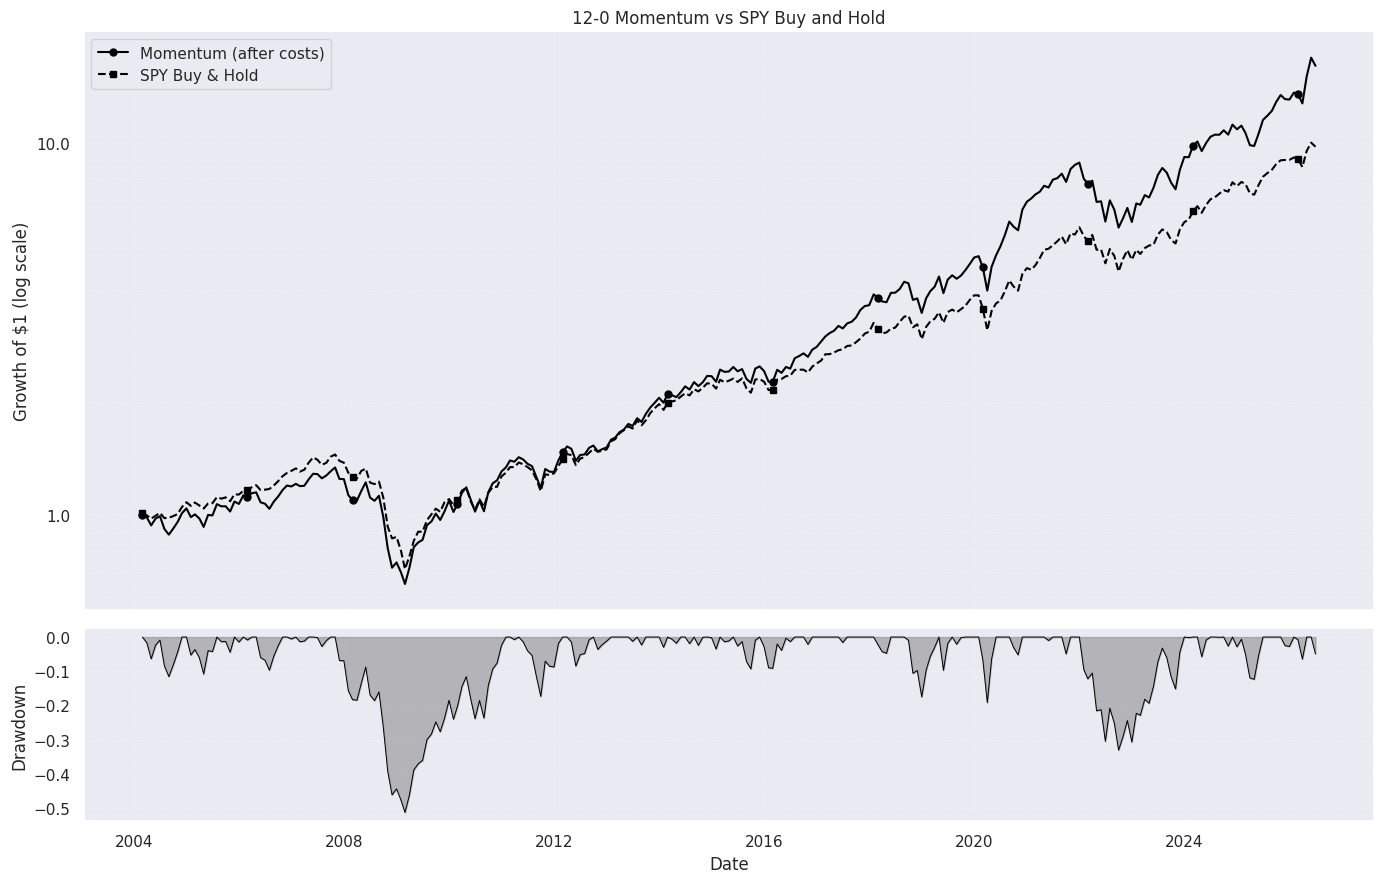

In [7]:
# Pull the after-costs strategy returns and the benchmark returns from the
# harness result, aligned to their common monthly window.
strat_daily = result.pf_costs.returns()
bench_daily = result.bench_returns

common = strat_daily.index.intersection(bench_daily.index)

# Resample both to monthly compounded returns, then build growth-of-$1 curves.
strat_monthly = (1 + strat_daily.loc[common]).resample("ME").prod() - 1
bench_monthly = (1 + bench_daily.loc[common]).resample("ME").prod() - 1

strat_curve = (1 + strat_monthly).cumprod()
bench_curve = (1 + bench_monthly).cumprod()

# Strategy drawdown: distance below the running peak of the equity curve.
strat_dd = strat_curve / strat_curve.cummax() - 1

# --- Plot: equity curve (log) on top, drawdown beneath ---
fig, (ax1, ax2) = plt.subplots(
    2, 1, figsize=(14, 9), sharex=True,
    gridspec_kw={"height_ratios": [3, 1]},
)

# Grayscale-safe: distinct line styles and markers, no reliance on color.
ax1.plot(strat_curve.index, strat_curve.values,
         color="black", linestyle="-", marker="o", markevery=24, markersize=5,
         label="Momentum (after costs)")
ax1.plot(bench_curve.index, bench_curve.values,
         color="black", linestyle="--", marker="s", markevery=24, markersize=5,
         label="SPY Buy & Hold")

# Log vertical axis: the strategy spans more than an order of magnitude.
ax1.set_yscale("log")
# Force plain numbers on the log axis, no scientific notation.
ax1.yaxis.set_major_formatter(mticker.ScalarFormatter())
ax1.yaxis.set_minor_formatter(mticker.NullFormatter())
ax1.set_ylabel("Growth of $1 (log scale)")
ax1.set_title("12-0 Momentum vs SPY Buy and Hold")
ax1.legend(loc="upper left")
ax1.grid(True, which="both", linestyle=":", linewidth=0.5, alpha=0.6)

# Drawdown panel, grayscale fill.
ax2.fill_between(strat_dd.index, strat_dd.values, 0,
                 color="gray", alpha=0.5)
ax2.plot(strat_dd.index, strat_dd.values, color="black", linewidth=0.7)
ax2.set_ylabel("Drawdown")
ax2.set_xlabel("Date")
ax2.grid(True, linestyle=":", linewidth=0.5, alpha=0.6)

plt.tight_layout()
plt.show()

The equity curve shows where the strategy earned its return and where it hurt:

- The two lines track closely from 2004 through about 2016, with the strategy neither clearly ahead nor behind for the first decade.
- The separation opens up after 2016 and widens through 2024, which is where most of the strategy's outperformance over SPY accumulates.
- The strategy is not a smoother ride. The drawdown panel shows the -51% trough in 2008 and 2009, and a second drawdown of roughly -35% in 2022, both comparable to or deeper than what a plain SPY holding endured.

The 2008 and 2009 trough is the key feature. A strategy that buys recent winners had loaded into the assets that were rising into the crisis, then rode them down as the trend reversed. This is the momentum crash, and it is the structural weakness of every trend-following and momentum system. We quantify how often it happens at the end of this notebook.

Before that, we look at what the strategy actually held over time.

## 8.0 Visualizing Holdings Over Time

The question this section answers: what did the strategy actually own, and when did it rotate between asset classes?

The equity curve shows the result of the strategy's choices but not the choices themselves. A holdings heatmap fills that gap. We build a grid with one row per fund and one column per month, and we shade a cell when that fund was among the five held that month. Reading across a row shows how long a fund stayed in the portfolio; reading down a column shows the five funds held at that date.

We order the rows by asset class, equity first, then fixed income, then alternatives, so that rotation between classes appears as shaded blocks moving between the three bands. This is where the cross-asset behavior of the strategy becomes visible.

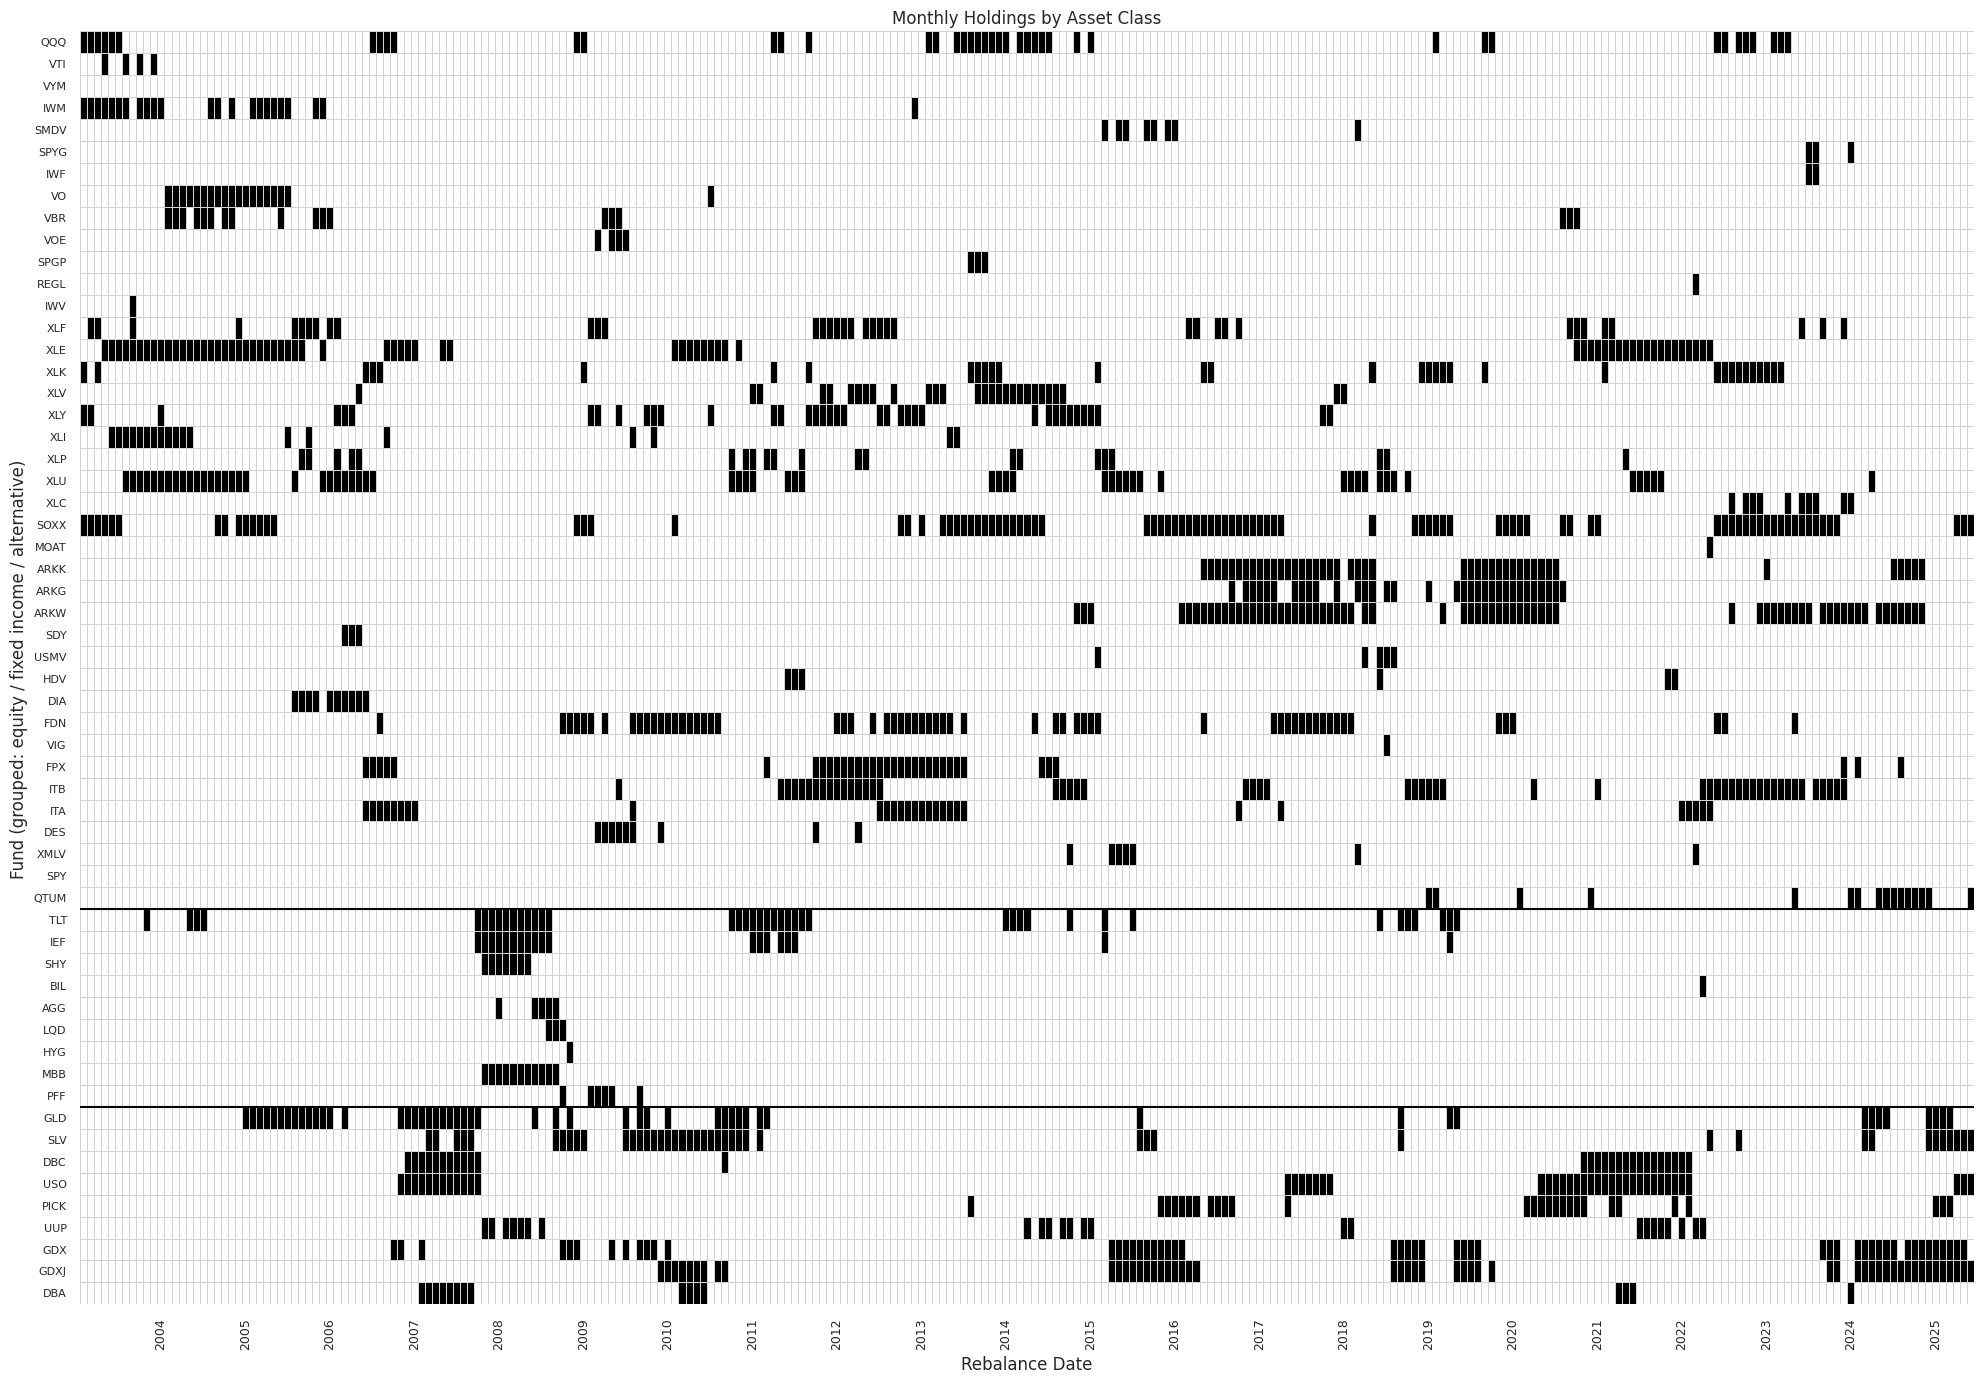

Average share of the 5 held slots by asset class (all months):
Alternative     0.251
Equity          0.680
Fixed Income    0.070
dtype: float64


In [8]:
import seaborn as sns


# Build a presence grid from the monthly buy lists: 1 if held that month, 0 if not.
# Rows ordered by asset class so rotation between classes is visible as bands.
class_order = list(equity_etfs) + list(fixed_income_etfs) + list(other_etfs)

# Start from the dense weights frame (NaN = not held), convert to a 0/1 grid.
presence = weights_dense[class_order].notna().astype(int)

# Transpose: rows = funds (by class), columns = months.
heat_data = presence.T

fig, ax = plt.subplots(figsize=(20, 14))

# Greys colormap for print: held cells dark, empty cells white.
# linewidths + linecolor draw the cell grid so every fund-month is a clean box.
sns.heatmap(
    heat_data,
    cmap="Greys",
    vmin=0, vmax=1,
    cbar=False,
    linewidths=0.5,
    linecolor="lightgray",
    ax=ax,
)

# Y axis: every fund, horizontal labels.
ax.set_yticks(np.arange(len(heat_data.index)) + 0.5)
ax.set_yticklabels(heat_data.index, fontsize=8, rotation=0)

# X axis: one tick per year-end to keep the 269-month axis readable.
year_positions = [i + 0.5 for i, d in enumerate(heat_data.columns) if d.month == 12]
year_labels = [d.year for d in heat_data.columns if d.month == 12]
ax.set_xticks(year_positions)
ax.set_xticklabels(year_labels, rotation=90, fontsize=9)

# Heavier divider lines between the three asset-class bands.
n_equity = len(equity_etfs)
n_fixed = len(fixed_income_etfs)
ax.axhline(n_equity, color="black", linewidth=1.5)
ax.axhline(n_equity + n_fixed, color="black", linewidth=1.5)

ax.set_xlabel("Rebalance Date")
ax.set_ylabel("Fund (grouped: equity / fixed income / alternative)")
ax.set_title("Monthly Holdings by Asset Class")

plt.tight_layout()
plt.show()

# Quick numeric summary of how often each asset class was held.
class_of = {t: "Equity" for t in equity_etfs}
class_of.update({t: "Fixed Income" for t in fixed_income_etfs})
class_of.update({t: "Alternative" for t in other_etfs})

# For each month, count holdings by class, then average across all months.
class_counts = presence.rename(columns=class_of).T.groupby(level=0).sum().T
class_share = (class_counts / TOP_N).mean().round(3)
print("Average share of the 5 held slots by asset class (all months):")
print(class_share)

Averaged across all 269 months, the five held slots split by asset class as:

- **Equity:** 68.0%
- **Alternative:** 25.1%
- **Fixed Income:** 7.0%

The heatmap shows this is not a steady blend but a rotation that concentrates in one class at a time:

- **Equity** dominates most of the record, and within it the holdings drift from broad and cyclical sectors early to growth and innovation funds later, with SOXX, ARKK, and ARKW filling long stretches after 2016.
- **Alternative** funds take over in distinct windows: commodities and gold in 2005 through 2008, again in 2010 and 2011, and a heavy precious-metals and oil tilt in 2024 and 2025.
- **Fixed Income** appears almost only in 2008 and 2009, with brief reappearances in 2011 and 2019. Bonds rank into the top five only when both equities and commodities are falling, which is exactly the flight-to-safety condition where treasuries lead.

The bond band confirms the cross-asset claim works as a defense mechanism. The strategy does not hold bonds for diversification. It rotates into them only when nothing else is trending up, which is the behavior that lets a single momentum rule act as a dynamic asset allocator.

The fixed-income concentration in 2008 also raises a question the equity curve already hinted at. If the strategy rotated into bonds during the crisis, why did it still suffer a 51% drawdown? We answer that next.

## 9.0 The Momentum Crash

The question this section answers: how often does this strategy put a holder through a severe loss, and why does buying winners produce those losses?

Momentum strategies share a structural weakness. They hold whatever has been rising, so they are by construction fully loaded into the prevailing trend at the moment it reverses. When a long uptrend breaks, the strategy is positioned in exactly the assets that fall hardest, and it cannot react until the next monthly rebalance. The result is a sharp, deep drawdown that researchers call the momentum crash.

We measure how serious this is for our strategy by counting distinct peak-to-trough drawdown episodes that reached -25% or worse. A single episode runs from a prior peak, down to its lowest point, and back to a new peak. Counting episodes rather than months tells us how many separate times a holder would have watched a quarter or more of their capital disappear.

In [9]:
# Report drawdown episodes that breach this depth. Edit here to change the cutoff.
DRAWDOWN_THRESHOLD = -15.0   # in percent

# Use the after-costs strategy as the basis, on the same monthly series scored.
strat_monthly_ret = (1 + result.pf_costs.returns()).resample("ME").prod() - 1

# Growth of $1 and the drawdown series (distance below running peak).
cum = (1 + strat_monthly_ret).cumprod()
running_max = cum.cummax()
drawdown = (cum - running_max) / running_max

# find_drawdown_episodes (functions.py) returns ranked episodes with start,
# trough, recovery, depth, and duration. top_n large enough to capture all.
episodes = fn.find_drawdown_episodes(cum, drawdown, top_n=100,
                                     period_unit="months")

# Parse the depth back to a number so we can filter on the threshold.
episodes["DepthNum"] = episodes["Depth"].str.rstrip("%").astype(float)

# Episodes that breached the threshold set above.
severe = episodes[episodes["DepthNum"] <= DRAWDOWN_THRESHOLD].copy()

years = (cum.index[-1] - cum.index[0]).days / 365.25
print(f"Total drawdown episodes on record: {len(episodes)}")
print(f"Episodes that reached {DRAWDOWN_THRESHOLD:.0f}% or worse: {len(severe)}")
print(f"\nYears in backtest: {years:.1f}")
if len(severe) > 0:
    print(f"Roughly one {DRAWDOWN_THRESHOLD:.0f}% episode every "
          f"{years / len(severe):.1f} years")

print(f"\nDrawdown episodes ({DRAWDOWN_THRESHOLD:.0f}% or worse):")
print(severe[["Start", "Trough", "Recovery", "Depth", "Duration (months)"]].to_string())

Total drawdown episodes on record: 43
Episodes that reached -15% or worse: 5

Years in backtest: 22.3
Roughly one -15% episode every 4.5 years

Drawdown episodes (-15% or worse):
           Start      Trough    Recovery    Depth  Duration (months)
Rank                                                                
1     2007-10-31  2009-02-28  2011-01-31  -51.36%                 40
2     2021-12-31  2022-09-30  2023-12-31  -33.11%                 25
3     2020-01-31  2020-03-31  2020-05-31  -19.21%                  5
4     2018-08-31  2018-12-31  2019-04-30  -17.54%                  9
5     2011-04-30  2011-09-30  2012-02-29  -17.39%                 11


Five episodes over 22 years is one severe drawdown roughly every four and a half years. To judge whether that is unusual to momentum or just the cost of being in the market, we run the same episode count on SPY buy-and-hold, on the same monthly basis and the same threshold.

In [10]:
# Same drawdown-episode analysis applied to SPY buy-and-hold, same threshold.
bench_monthly_ret = (1 + result.bench_returns).resample("ME").prod() - 1

cum_spy = (1 + bench_monthly_ret).cumprod()
running_max_spy = cum_spy.cummax()
drawdown_spy = (cum_spy - running_max_spy) / running_max_spy

episodes_spy = fn.find_drawdown_episodes(cum_spy, drawdown_spy, top_n=100,
                                         period_unit="months")
episodes_spy["DepthNum"] = episodes_spy["Depth"].str.rstrip("%").astype(float)
severe_spy = episodes_spy[episodes_spy["DepthNum"] <= DRAWDOWN_THRESHOLD].copy()

years_spy = (cum_spy.index[-1] - cum_spy.index[0]).days / 365.25
print(f"SPY total drawdown episodes on record: {len(episodes_spy)}")
print(f"SPY episodes that reached {DRAWDOWN_THRESHOLD:.0f}% or worse: {len(severe_spy)}")
if len(severe_spy) > 0:
    print(f"Roughly one {DRAWDOWN_THRESHOLD:.0f}% episode every "
          f"{years_spy / len(severe_spy):.1f} years")

print(f"\nSPY drawdown episodes ({DRAWDOWN_THRESHOLD:.0f}% or worse):")
print(severe_spy[["Start", "Trough", "Recovery", "Depth", "Duration (months)"]].to_string())

SPY total drawdown episodes on record: 37
SPY episodes that reached -15% or worse: 3
Roughly one -15% episode every 7.4 years

SPY drawdown episodes (-15% or worse):
           Start      Trough    Recovery    Depth  Duration (months)
Rank                                                                
1     2007-10-31  2009-02-28  2012-03-31  -50.78%                 54
2     2021-12-31  2022-09-30  2023-12-31  -23.93%                 25
3     2019-12-31  2020-03-31  2020-07-31  -19.45%                  8


The two episode tables put the momentum-crash risk in context:

| | Momentum | SPY Buy & Hold |
|---|---|---|
| Episodes of -15% or worse | 5 | 3 |
| Frequency | ~1 every 4.5 years | ~1 every 7.4 years |
| Worst episode | -51.4% (2007-2009) | -50.8% (2007-2009) |
| Second worst | -33.1% (2021-2022) | -23.9% (2021-2022) |

What the comparison shows:

- The strategy reaches a -15% drawdown about two-thirds more often than SPY: five episodes against three over the same window.
- The two worst episodes line up in time with SPY's, but the momentum version is deeper. In 2021-2022 the strategy lost a third of its value while SPY lost a quarter, because the strategy was loaded into the 2021 growth and innovation winners (ARKK, ARKW, QTUM) precisely as that trend broke.
- The strategy carries two extra severe episodes that SPY avoided entirely, in 2018 and 2011, both cases where a trend the strategy had committed to reversed sharply.

The 2007-2009 episode is where the crash mechanism is clearest. The strategy did rotate into bonds during the crisis, visible in the holdings heatmap, but it rotated late. Momentum acts on a 12-month lookback and rebalances monthly, so it stayed in falling equities and commodities well into the decline before the ranking finally favored treasuries. By then most of the damage was done. The recovery was also slow: the strategy took 40 months to reach a new peak, though that is faster than SPY's 54 months for the same crash.

This is the central tradeoff of momentum. It compounds faster than the market over the full record, but it pays for that with deeper and more frequent crashes, and it crashes hardest exactly when a long trend reverses. A reader considering this strategy should size it knowing that a 15% drawdown is a roughly four-to-five-year event and a 30%-plus drawdown is on the table.

This is why you need to stick with momentum strategies and understand it must be followed with discipline for at least 3-5 years.

## 10.0 Rolling Returns Analysis

The question this section answers: how consistent is the strategy's edge over SPY, rather than how large it is over the full record?

A single full-period CAGR hides the path. A strategy can post a strong final number while losing to the benchmark for years at a stretch, which is exactly the experience that makes a real holder abandon it. Rolling returns address this by measuring performance over every overlapping window of a fixed length, so we see the range of outcomes a holder could actually have lived through.

We use a 36-month, or three-year, window. For each month we compute the annualized return over the trailing three years for both the strategy and SPY, then summarize the best, worst, and average three-year outcome, and the share of three-year windows in which the strategy beat SPY.

In [11]:
# Assemble a two-column monthly return frame: strategy (after costs) and SPY,
# aligned to their common window. calculate_rolling_returns expects monthly
# decimal returns with one column per series.
strat_m = (1 + result.pf_costs.returns()).resample("ME").prod() - 1
bench_m = (1 + result.bench_returns).resample("ME").prod() - 1

common_idx = strat_m.index.intersection(bench_m.index)
df_rets = pd.DataFrame({
    "Momentum": strat_m.loc[common_idx],
    "SPY": bench_m.loc[common_idx],
})

# 36-month (3-year) rolling window, annualized inside the helper.
ROLL_WINDOW = 36
rolling = fn.calculate_rolling_returns(df_rets, window=ROLL_WINDOW)

# Best / worst / average 3-year outcome, and share of windows beating SPY.
stats = fn.rolling_return_stats(rolling, benchmark_col="SPY")

print(f"Rolling {ROLL_WINDOW}-month (annualized) return statistics:")
print(stats.to_string())

# Count of valid (non-NaN) windows for context on sample size.
n_windows = rolling["Momentum"].dropna().shape[0]
print(f"\nNumber of 3-year windows evaluated: {n_windows}")

Rolling 36-month (annualized) return statistics:
         Best Period Worst Period Avg Period Beat Benchmark
Momentum      36.34%      -16.47%     13.27%          79.1%
SPY           25.97%      -15.08%     10.66%           0.0%

Number of 3-year windows evaluated: 234


Across 234 overlapping three-year windows, the strategy beat SPY in 79.1% of them.

That figure is the one to focus on. The full-period CAGR already told us the strategy won over 22 years, but a single number cannot say whether the edge was steady or the product of a few lucky stretches. The rolling result settles it: in roughly four of every five three-year periods a holder would have come out ahead of simply owning the S&P 500.

The rest of the table supports the same read:

- **Best three-year window:** 36.3% annualized for the strategy versus 26.0% for SPY
- **Average three-year window:** 13.3% versus 10.7%
- **Worst three-year window:** -16.5% versus -15.1%

The strategy's worst three-year stretch is only marginally deeper than SPY's, so the higher beat rate does not come from taking wildly more three-year downside. The edge is persistent rather than concentrated, which is the property that makes a strategy survivable to hold in practice. The one-in-five windows where it lagged are the price of the crash risk we measured in the previous section, and they cluster around the same trend reversals.

## 11.0 Summary

In this notebook we built the classic 12-0 momentum strategy and tested it across asset classes. We ranked a 58-fund universe by trailing 12-month return each month, held the top five in equal weight, and rebalanced monthly, with no filter and no defensive override.

What we found:

- The strategy compounded at 13.2% a year after costs against 10.7% for SPY, turning one dollar into roughly fifteen over 22 years.
- The edge was persistent, not concentrated. It beat SPY in 79% of all three-year windows.
- Trading costs were immaterial at this turnover, with the after-costs result statistically indistinguishable from the no-cost run.
- The cross-asset universe let a single momentum rule act as a dynamic asset allocator, rotating into commodities when they led and into treasuries during the 2008 crisis, all without instruction.

The cost of that edge is drawdown. The strategy reached a -15% loss about once every 4.5 years against once every 7.4 years for SPY, and its worst episodes were deeper, including a -51% crash in 2008 and 2009 and a -33% crash in 2021 and 2022. This is the momentum crash: a strategy that buys winners is by construction fully exposed to the prevailing trend at the moment it reverses, and a monthly rebalance reacts too slowly to escape the initial fall.

The lesson is that momentum is a return engine, not a risk reducer. It earns its long-run premium by accepting sharp, periodic crashes that a passive holding would not. Sizing the strategy means planning for those crashes rather than being surprised by them.

In the next notebook, 13.7 Multi-Period Moving Average Strategy for Bitcoin, we take the same backtest machinery to a single volatile asset and combine several moving-average signals into one position, showing how a momentum idea adapts from a cross-sectional ETF universe to a single-asset trend system.

## Reference

- Jegadeesh, N. and Titman, S. (1993). Returns to Buying Winners and Selling Losers: Implications for Stock Market Efficiency. *The Journal of Finance*, 48(1), 65-91.
https://doi.org/10.1111/j.1540-6261.1993.tb04702.x